# 01 — Shock Propagation Simulation (Laber et al. 2023 baseline)

Replicates the Laber et al. (2023) *Nature Food* simulation framework on the 2018 World Input-Output Network (WION).

**Baseline dynamic model**: $x_{t+1} = A x_t$

**Relative Loss**: $RL_j(t) = \\frac{x_j^{\\text{base}}(t) - x_j^{\\text{shock}}(t)}{x_j^{\\text{base}}(t)}$

---
### Three shock scenarios
1. **Single-node shock** — e.g. Russian petroleum (`RUS_C19`)
2. **Single-country shock** — e.g. all of Russia (`RUS`)
3. **Multi-node shock** — e.g. Ukraine war (agriculture + energy nodes)


In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Project imports ───────────────────────────────────────────────────────────
from src.network.builder import build_matrices
from src.simulation.simulator import ShockSimulator

print('Imports OK')

Imports OK


In [7]:
# Create outputs directory if it doesn't exist
os.makedirs('../outputs', exist_ok=True)

## 0. Load matrices

In [2]:
Z, F, X, A, B = build_matrices(2018)

print(f'A matrix shape : {A.shape}')
print(f'Nodes          : {len(A.index)}')
print(f'Sample nodes   : {list(A.index[:5])}')

Active nodes after zero-output removal: 3928
A matrix shape : (3928, 3928)
Nodes          : 3928
Sample nodes   : ['AGO_A01', 'AGO_A02', 'AGO_A03', 'AGO_B05', 'AGO_B06']


In [3]:
# ── Initialise simulator ──────────────────────────────────────────────────────
# n_iter=10 matches Laber et al. (one iteration ≈ one model year)
# phi=1.0   matches their worst-case complete production loss

sim = ShockSimulator(A, X, n_iter=10, phi=1.0)

print(f'Simulator ready — {sim.n} nodes, {sim.n_iter} iterations')

Simulator ready — 3928 nodes, 10 iterations


---
## Scenario 1 — Single-node shock

**RUS_C19** = Russian petroleum refining.  
Identified in EDA as one of the top supply-side hubs (high out-degree, high PageRank).

This mirrors Laber et al.'s Ukrainian maize case: one critical node knocked out, observe global RL cascade.

In [4]:
# ── Pick the shock node ───────────────────────────────────────────────────────
# Change this to any node label in A.index
SHOCK_NODE = 'RUS_C19'

# Confirm it exists
print(f'Node exists: {SHOCK_NODE in A.index}')

# Show some context: what does this node supply to?
top_buyers = A.loc[SHOCK_NODE].sort_values(ascending=False).head(10)
print(f'\nTop 10 buyers of {SHOCK_NODE}:')
print(top_buyers.to_string())

Node exists: True

Top 10 buyers of RUS_C19:
V1
RUS_H51    0.234431
RUS_C20    0.143322
RUS_H50    0.138119
RUS_C19    0.127791
RUS_A02    0.108683
BLR_H51    0.087491
RUS_A03    0.087175
BLR_C19    0.076321
RUS_H49    0.066725
BGR_C19    0.064897


In [5]:
results_1 = sim.run(
    shock=SHOCK_NODE,
    mode='single_node',
    label=f'Single node: {SHOCK_NODE}'
)


Shock: Single node: RUS_C19 | mode=single_node | nodes=1
Iterations: 10 | phi=1.0
Nodes with RL > 0.01 at t_end : 2025
Nodes with RL > 0.10 at t_end : 189
Max RL at t_end               : 1.0000 (RUS_C19)
Mean RL at t_end              : 0.0256


Saved: ../outputs/s1_timeseries.png


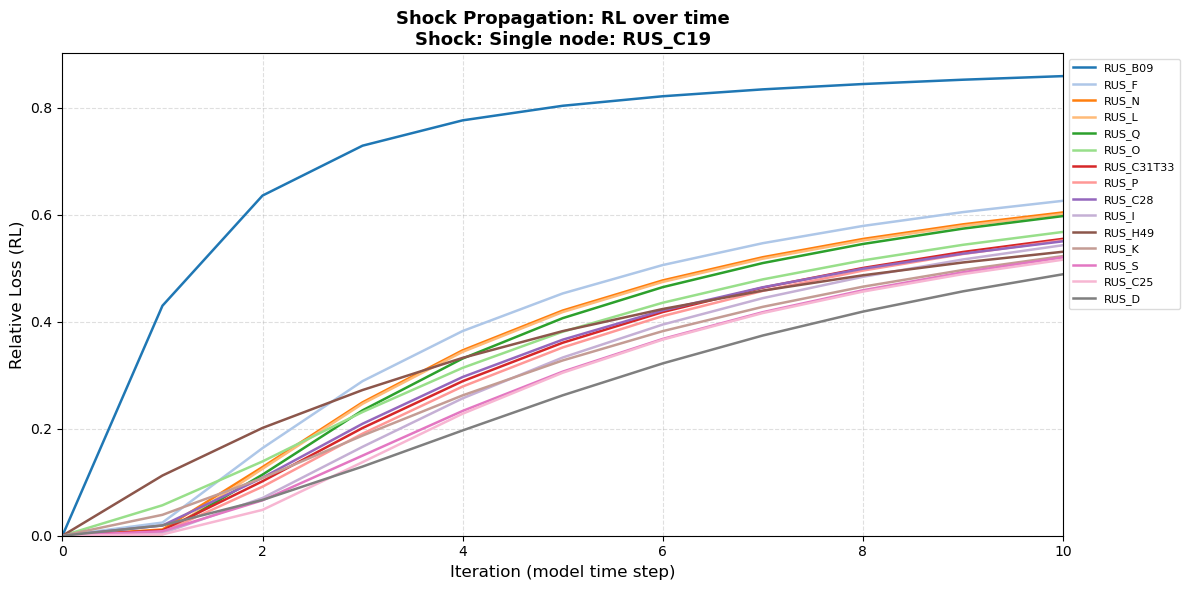

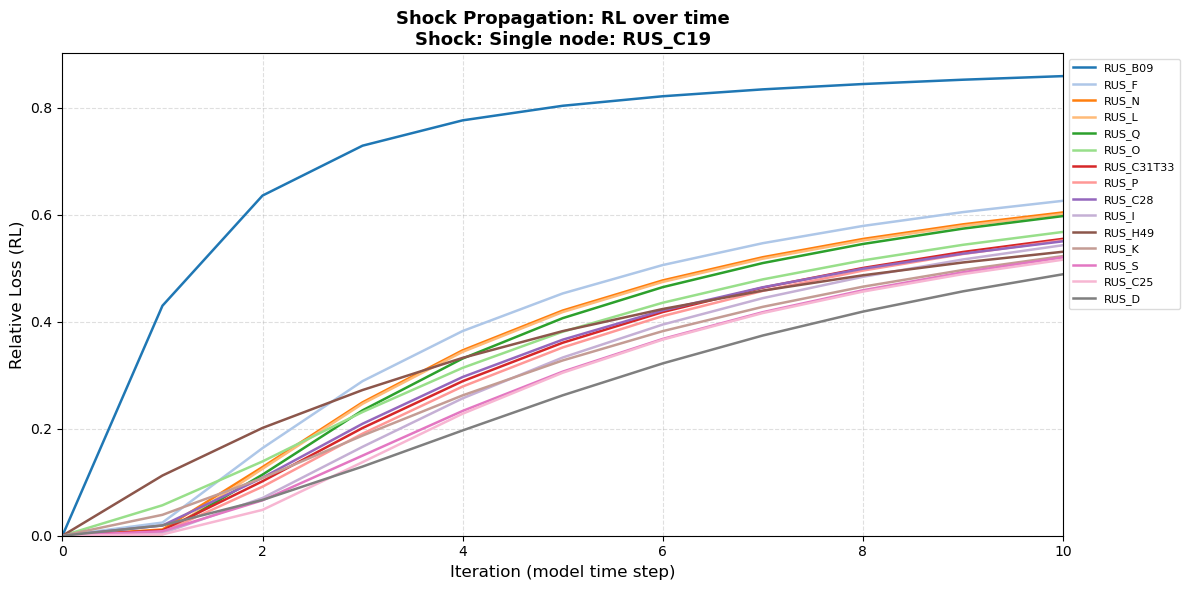

In [8]:
# ── Time-series: top 15 most affected nodes ───────────────────────────────────
sim.plot_rl_timeseries(
    results_1,
    top_n=15,
    save_path='../outputs/s1_timeseries.png'
)

Saved: ../outputs/s1_heatmap.png


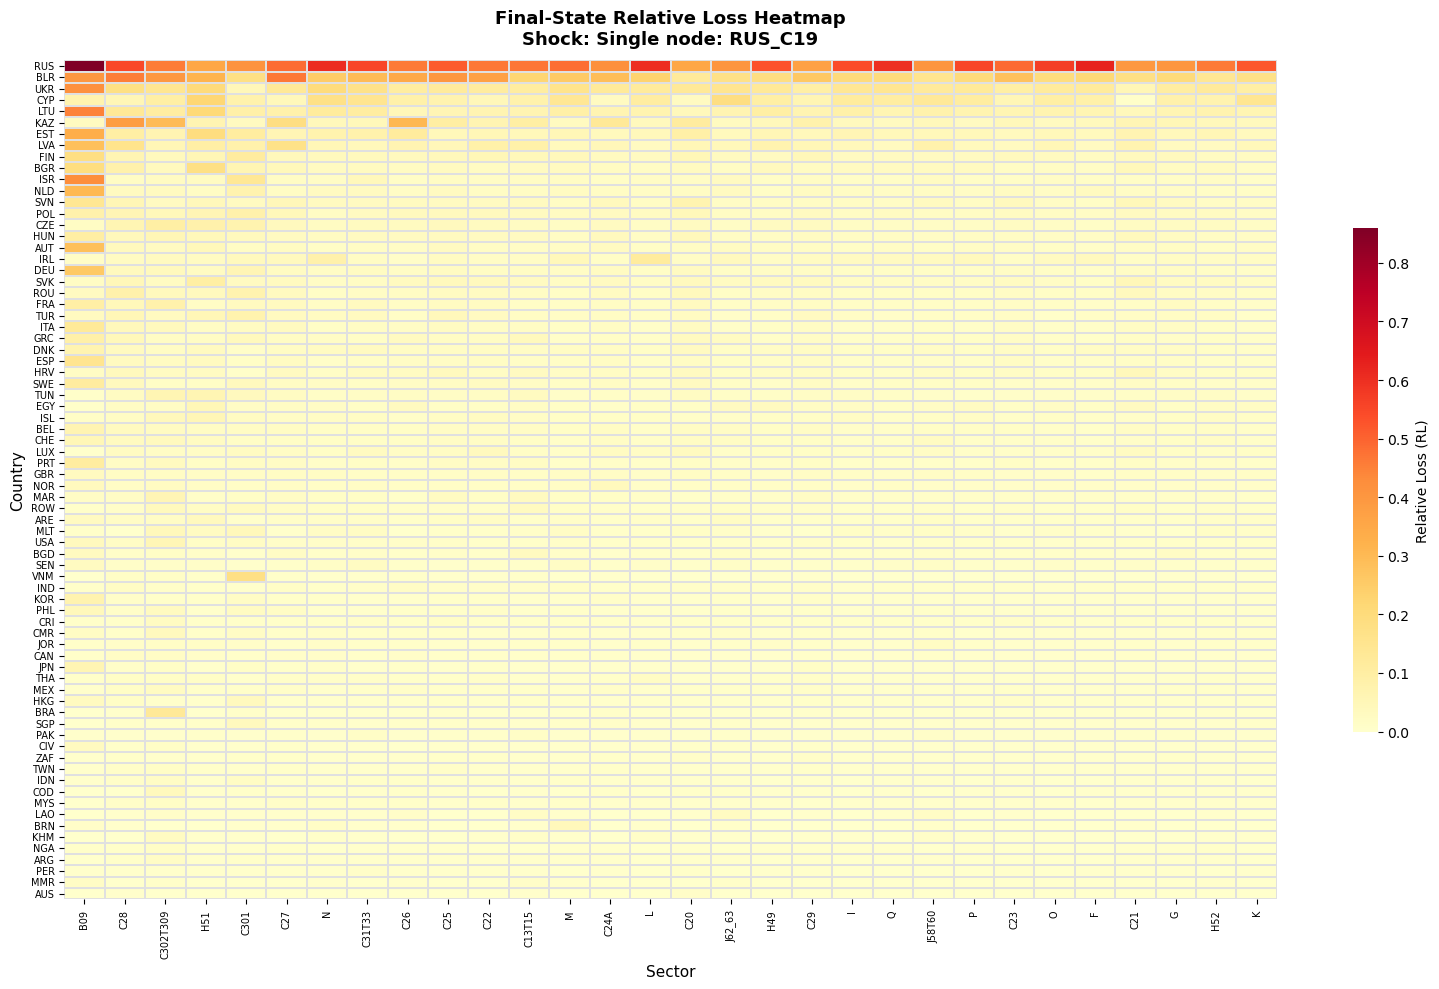

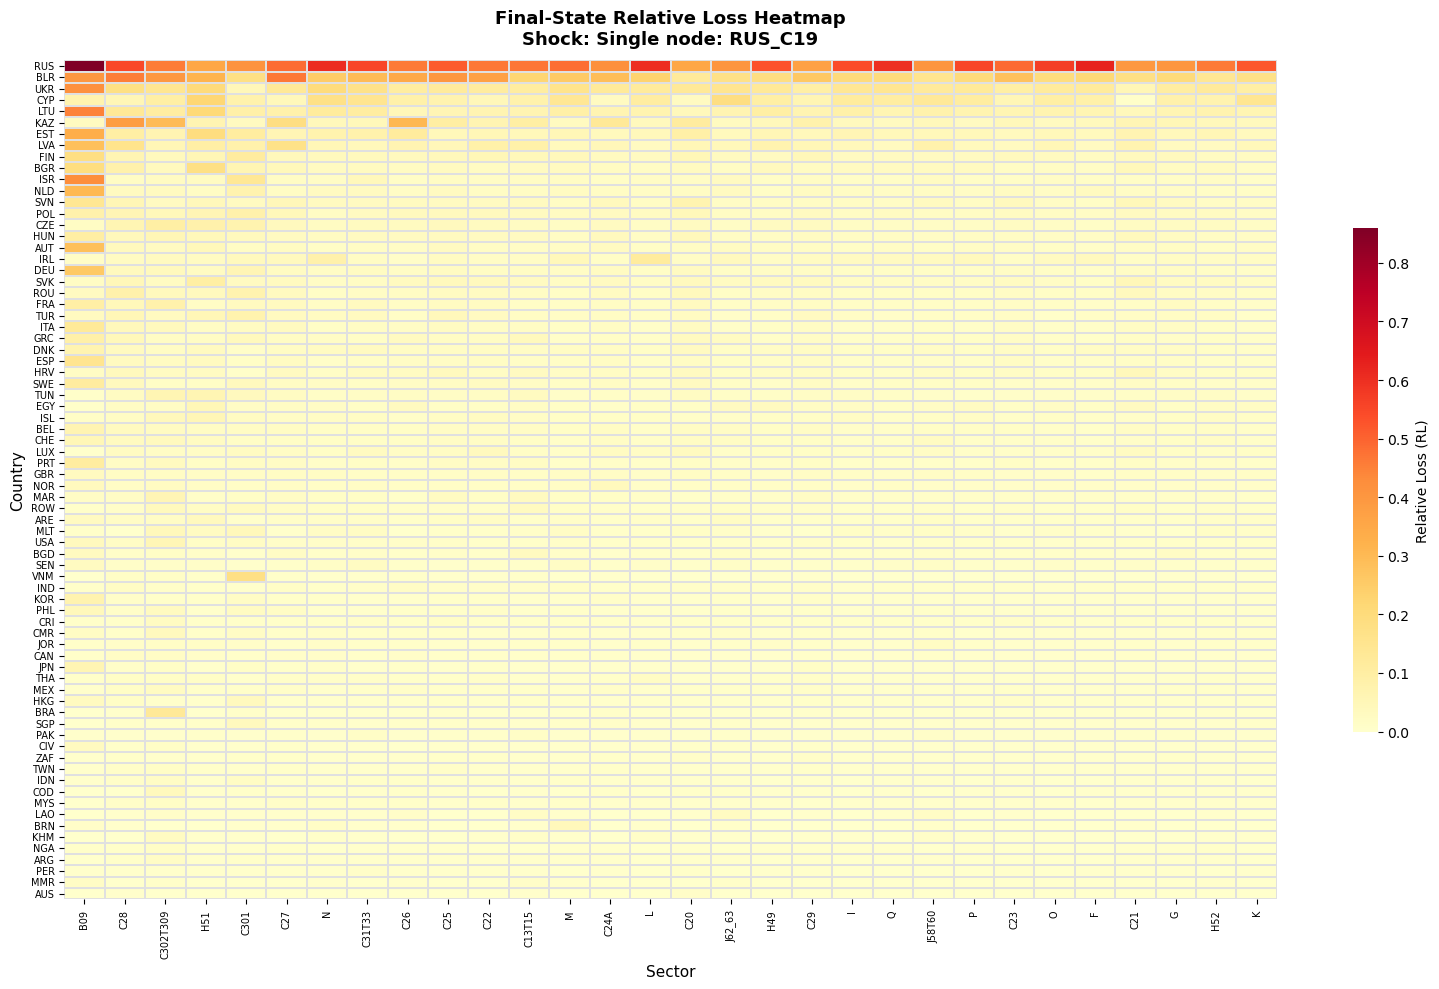

In [9]:
# ── Final-state heatmap ───────────────────────────────────────────────────────
sim.plot_rl_heatmap(
    results_1,
    top_n_nodes=30,
    save_path='../outputs/s1_heatmap.png'
)

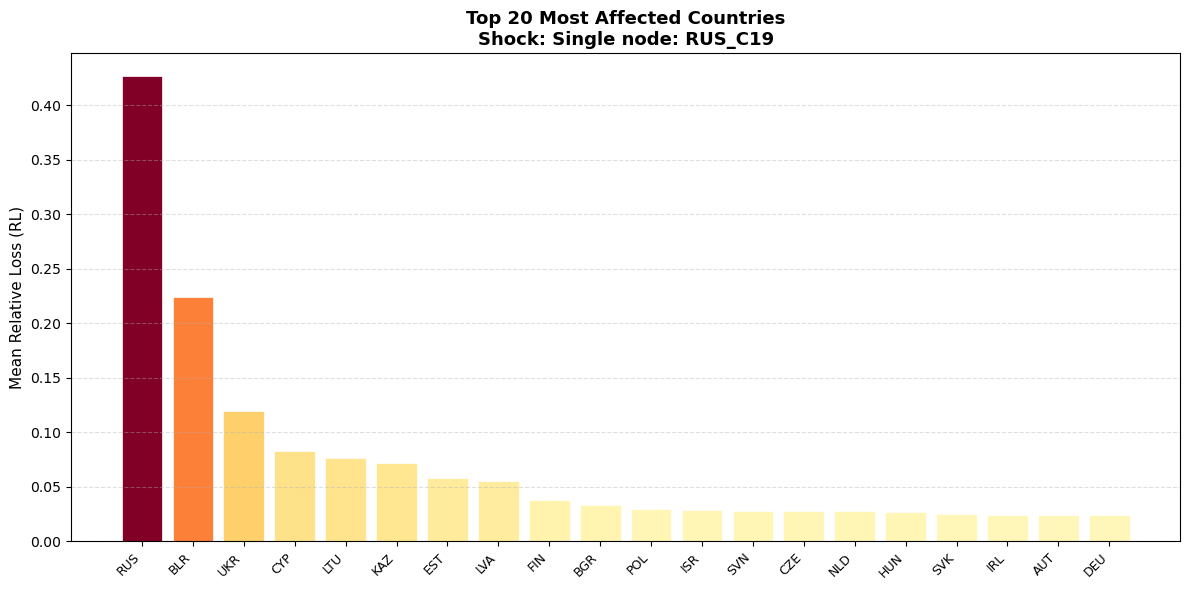

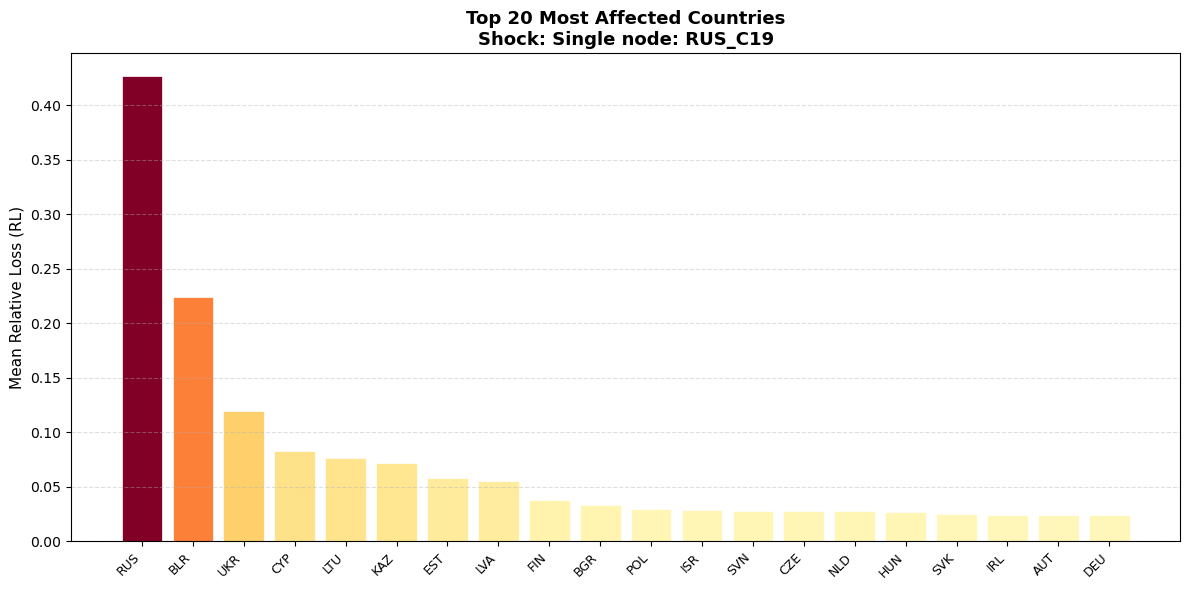

In [10]:
# ── Country-level bar chart ───────────────────────────────────────────────────
sim.plot_country_rl_bar(
    results_1,
    top_n=20,
    save_path='../outputs/s1_country_bar.png'
)

In [11]:
# ── Top 20 most affected nodes at t_end ──────────────────────────────────────
rl1 = results_1['RL_final'].drop(index=results_1['shock_nodes'], errors='ignore')
print('Top 20 most affected nodes (Scenario 1):')
print(rl1.nlargest(20).to_string())

Top 20 most affected nodes (Scenario 1):
V1
RUS_B09       0.859006
RUS_F         0.625951
RUS_N         0.604235
RUS_L         0.601191
RUS_Q         0.597392
RUS_O         0.567779
RUS_C31T33    0.554860
RUS_P         0.552049
RUS_C28       0.550289
RUS_I         0.542978
RUS_H49       0.530751
RUS_K         0.522670
RUS_S         0.520173
RUS_C25       0.515886
RUS_D         0.488666
RUS_C23       0.487783
RUS_C27       0.485222
RUS_M         0.482851
RUS_C13T15    0.467667
BLR_C27       0.463807


---
## Scenario 2 — Single-country shock

**Russia** — all nodes zeroed out simultaneously.  
Analogous to Laber et al.'s complete Ukraine agricultural loss scenario.

In [12]:
SHOCK_COUNTRY = 'RUS'

# Show all RUS nodes
rus_nodes = [n for n in A.index if n.startswith('RUS_')]
print(f'Total RUS nodes: {len(rus_nodes)}')
print(rus_nodes)

Total RUS nodes: 49
['RUS_A01', 'RUS_A02', 'RUS_A03', 'RUS_B05', 'RUS_B06', 'RUS_B07', 'RUS_B08', 'RUS_B09', 'RUS_C10T12', 'RUS_C13T15', 'RUS_C16', 'RUS_C17_18', 'RUS_C19', 'RUS_C20', 'RUS_C21', 'RUS_C22', 'RUS_C23', 'RUS_C24A', 'RUS_C24B', 'RUS_C25', 'RUS_C26', 'RUS_C27', 'RUS_C28', 'RUS_C29', 'RUS_C301', 'RUS_C302T309', 'RUS_C31T33', 'RUS_D', 'RUS_E', 'RUS_F', 'RUS_G', 'RUS_H49', 'RUS_H50', 'RUS_H51', 'RUS_H52', 'RUS_H53', 'RUS_I', 'RUS_J58T60', 'RUS_J61', 'RUS_J62_63', 'RUS_K', 'RUS_L', 'RUS_M', 'RUS_N', 'RUS_O', 'RUS_P', 'RUS_Q', 'RUS_R', 'RUS_S']


In [13]:
results_2 = sim.run(
    shock=SHOCK_COUNTRY,
    mode='single_country',
    label=f'Single country: {SHOCK_COUNTRY}'
)



Shock: Single country: RUS | mode=single_country | nodes=49
Iterations: 10 | phi=1.0
Nodes with RL > 0.01 at t_end : 3668
Nodes with RL > 0.10 at t_end : 388
Max RL at t_end               : 1.0000 (RUS_A01)
Mean RL at t_end              : 0.0622


Saved: ../outputs/s2_timeseries.png


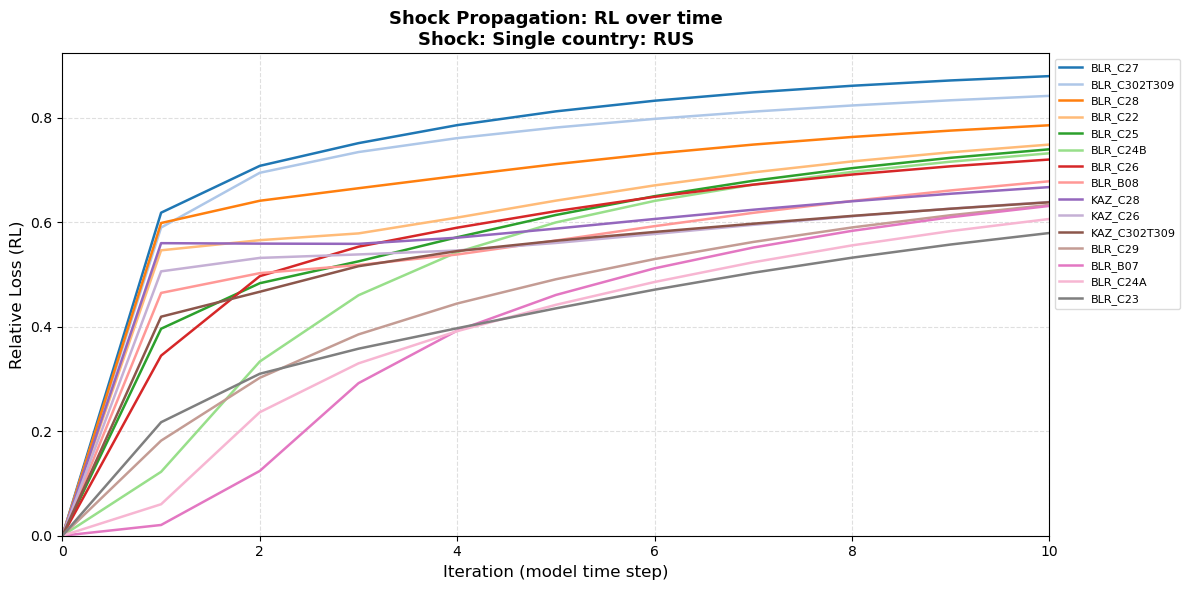

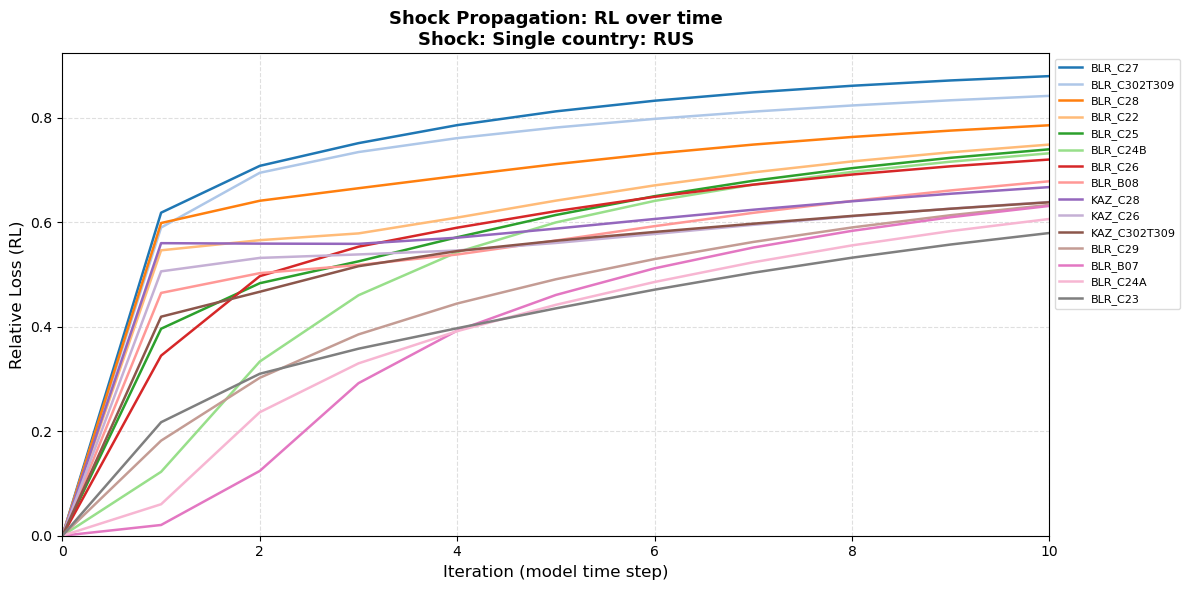

In [14]:
sim.plot_rl_timeseries(
    results_2,
    top_n=15,
    save_path='../outputs/s2_timeseries.png'
)

Saved: ../outputs/s2_heatmap.png


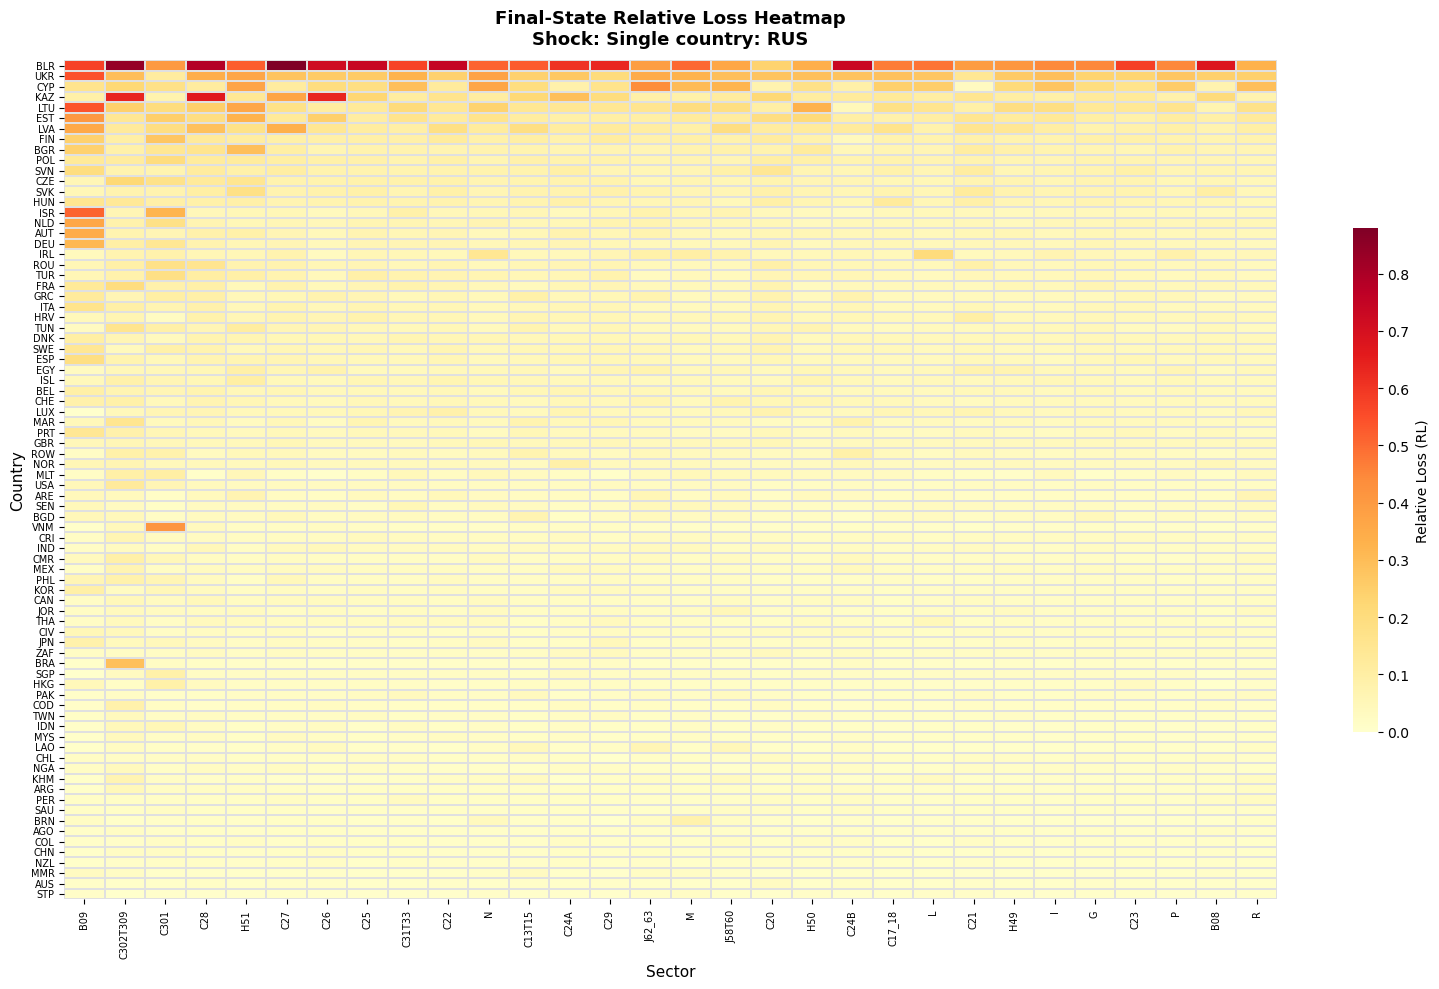

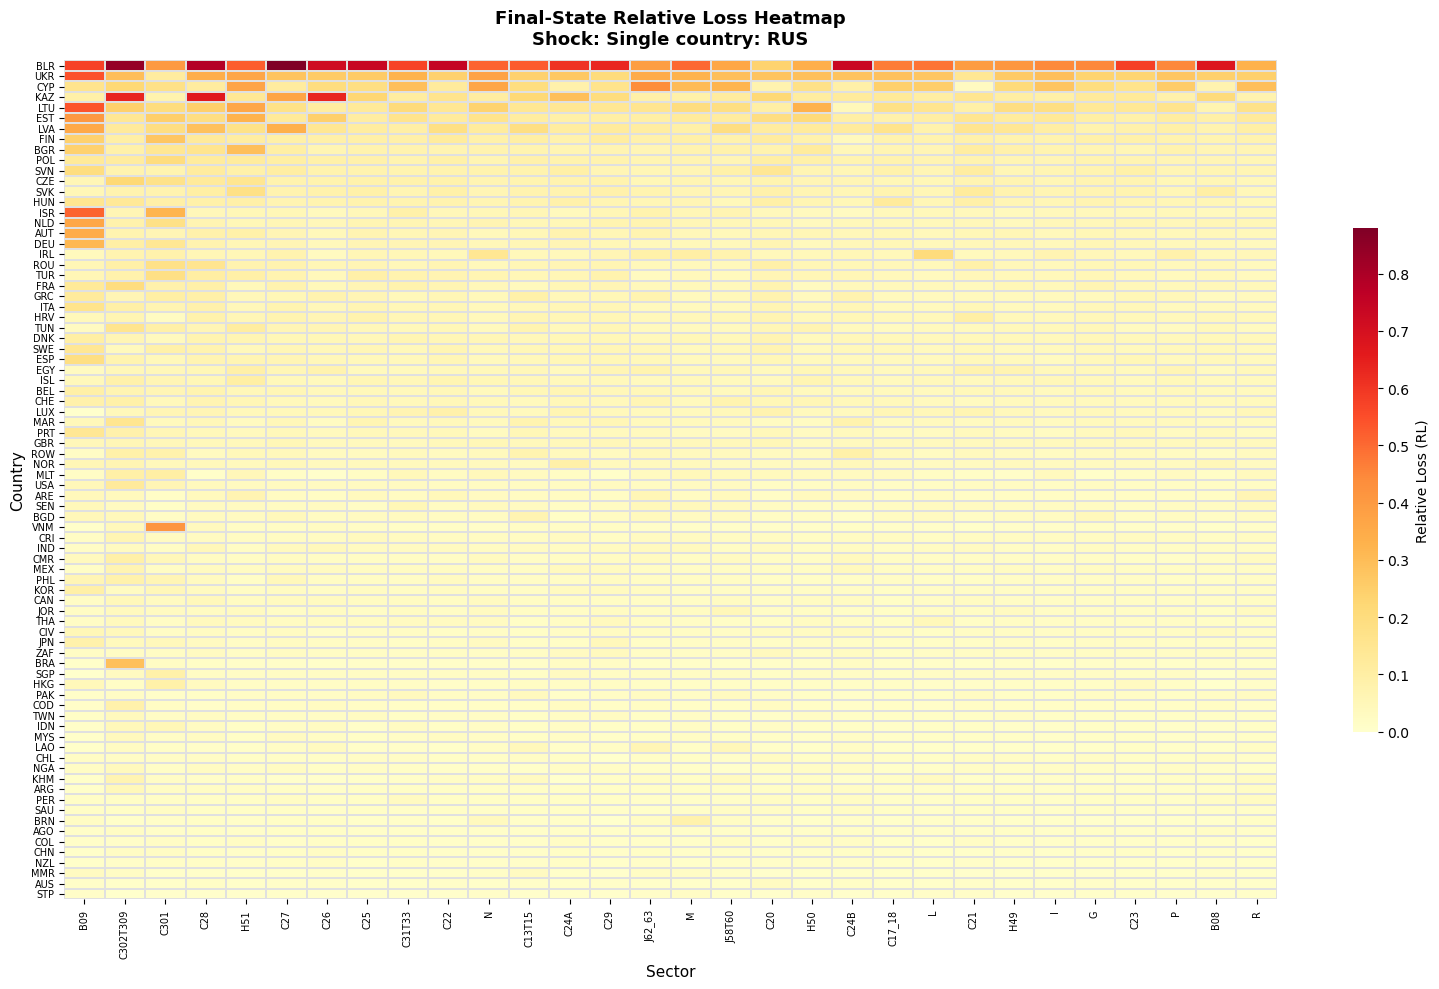

In [15]:
sim.plot_rl_heatmap(
    results_2,
    top_n_nodes=30,
    save_path='../outputs/s2_heatmap.png'
)

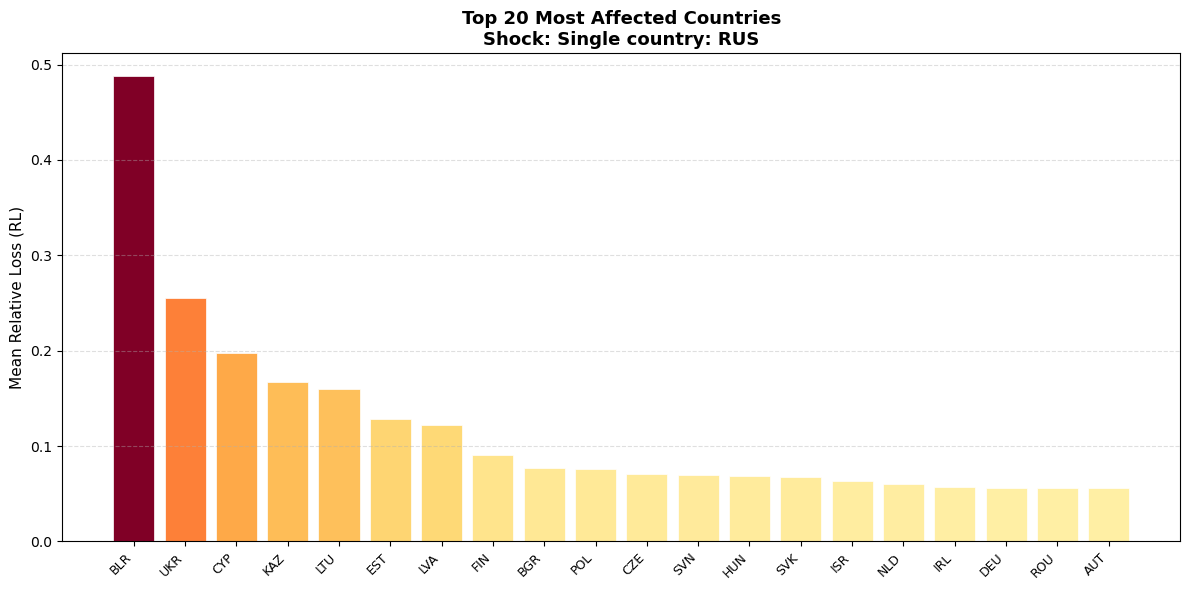

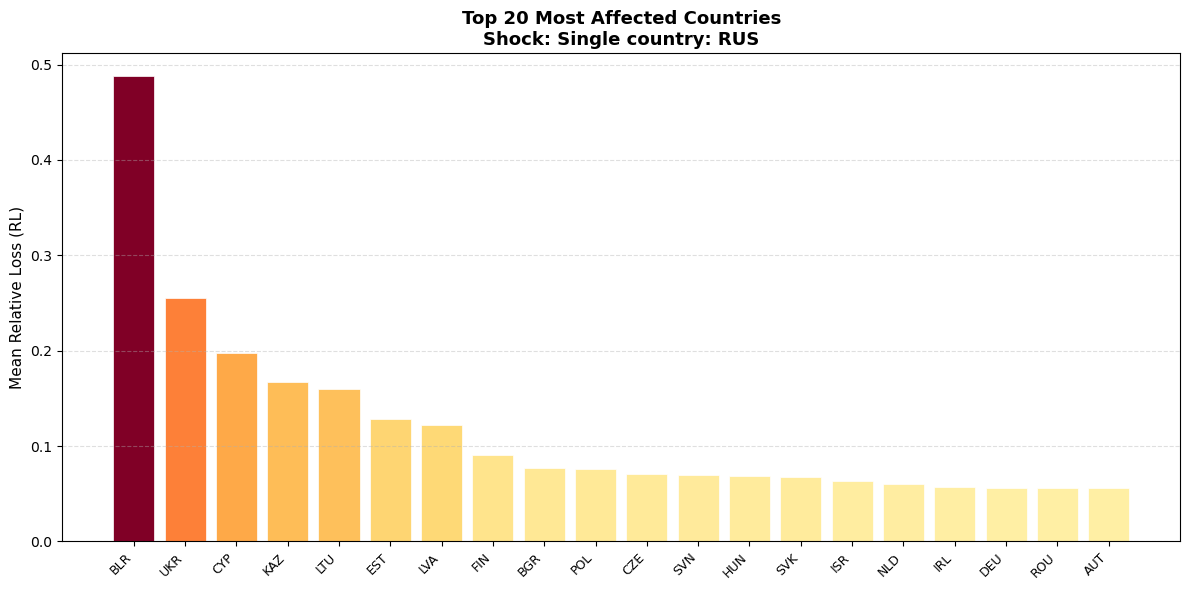

In [16]:
sim.plot_country_rl_bar(
    results_2,
    top_n=20,
    save_path='../outputs/s2_country_bar.png'
)

In [17]:
rl2 = results_2['RL_final'].drop(index=results_2['shock_nodes'], errors='ignore')
print('Top 20 most affected nodes (Scenario 2):')
print(rl2.nlargest(20).to_string())

Top 20 most affected nodes (Scenario 2):
V1
BLR_C27         0.879278
BLR_C302T309    0.841488
BLR_C28         0.785255
BLR_C22         0.748313
BLR_C25         0.739292
BLR_C24B        0.731677
BLR_C26         0.719721
BLR_B08         0.678112
KAZ_C28         0.666963
KAZ_C26         0.638542
KAZ_C302T309    0.637935
BLR_C29         0.632964
BLR_B07         0.630943
BLR_C24A        0.606001
BLR_C23         0.579137
BLR_B09         0.574459
BLR_C31T33      0.570480
UKR_B09         0.544501
LTU_B09         0.541056
BLR_C13T15      0.526998


---
## Scenario 3 — Multi-node shock (Ukraine war proxy)

Jointly shocks Ukraine's agriculture + energy nodes AND Russia's petroleum — 
a compound supply disruption mimicking the 2022 war scenario.

Edit `WAR_NODES` below to customise the shock set.


In [18]:
# ── Define the multi-node shock set ──────────────────────────────────────────
# UKR agriculture + energy, RUS petroleum
# Filter to only nodes that exist in our A matrix

CANDIDATE_NODES = [
    # Ukraine agriculture
    'UKR_A01', 'UKR_A02', 'UKR_A03',
    # Ukraine energy
    'UKR_B06', 'UKR_B07', 'UKR_B08', 'UKR_C19',
    # Russia petroleum
    'RUS_C19', 'RUS_B06',
]

WAR_NODES = [n for n in CANDIDATE_NODES if n in A.index]
print(f'Shock nodes ({len(WAR_NODES)}):')
for n in WAR_NODES:
    print(f'  {n}')

Shock nodes (9):
  UKR_A01
  UKR_A02
  UKR_A03
  UKR_B06
  UKR_B07
  UKR_B08
  UKR_C19
  RUS_C19
  RUS_B06


In [19]:
results_3 = sim.run(
    shock=WAR_NODES,
    mode='multi_node',
    label='Multi-node: Ukraine war proxy'
)


Shock: Multi-node: Ukraine war proxy | mode=multi_node | nodes=9
Iterations: 10 | phi=1.0
Nodes with RL > 0.01 at t_end : 2421
Nodes with RL > 0.10 at t_end : 246
Max RL at t_end               : 1.0000 (RUS_B06)
Mean RL at t_end              : 0.0388


Saved: ../outputs/s3_timeseries.png


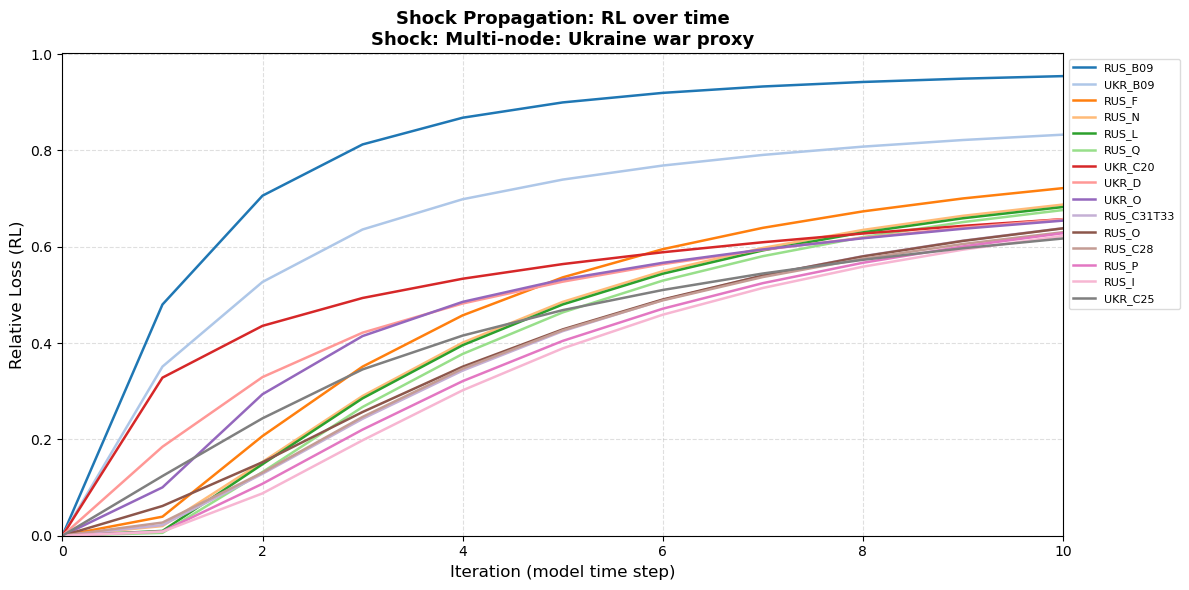

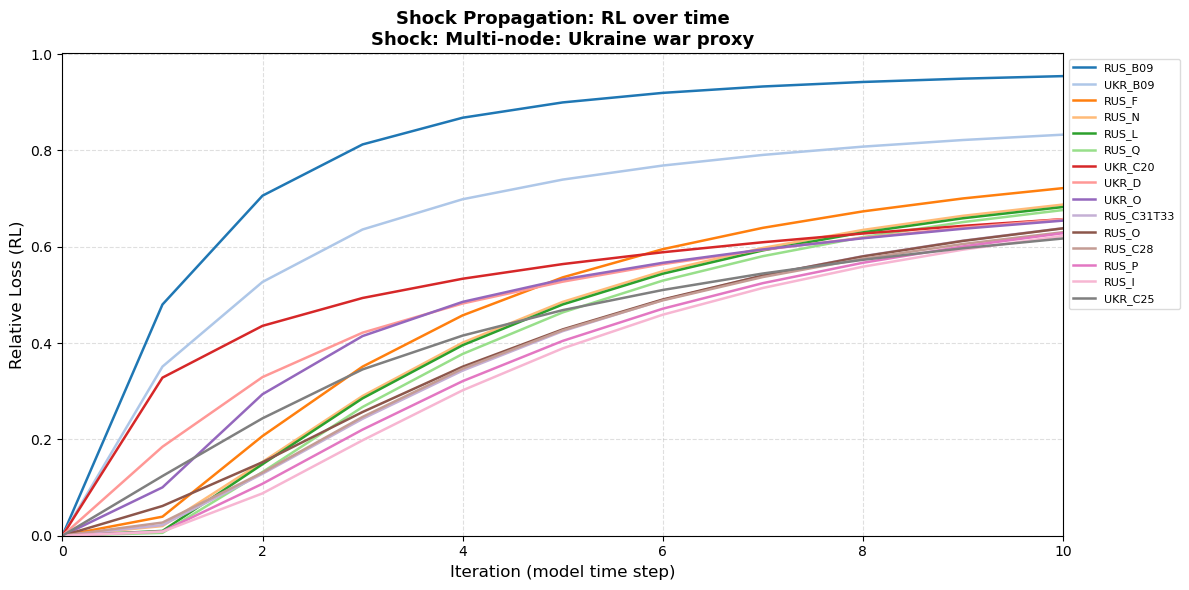

In [20]:
sim.plot_rl_timeseries(
    results_3,
    top_n=15,
    save_path='../outputs/s3_timeseries.png'
)

Saved: ../outputs/s3_heatmap.png


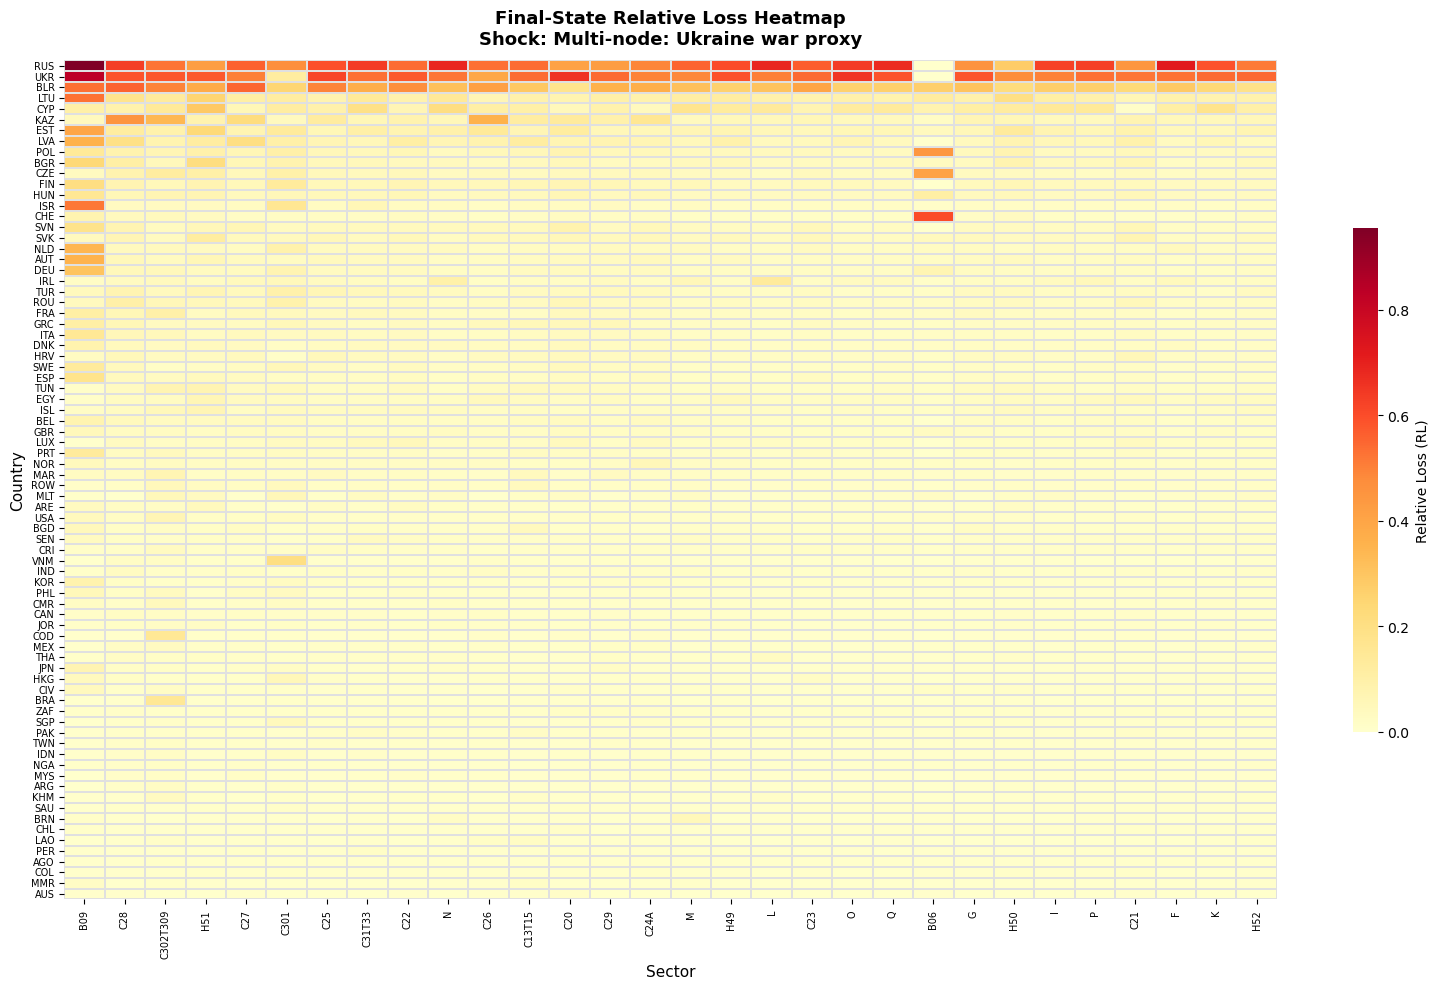

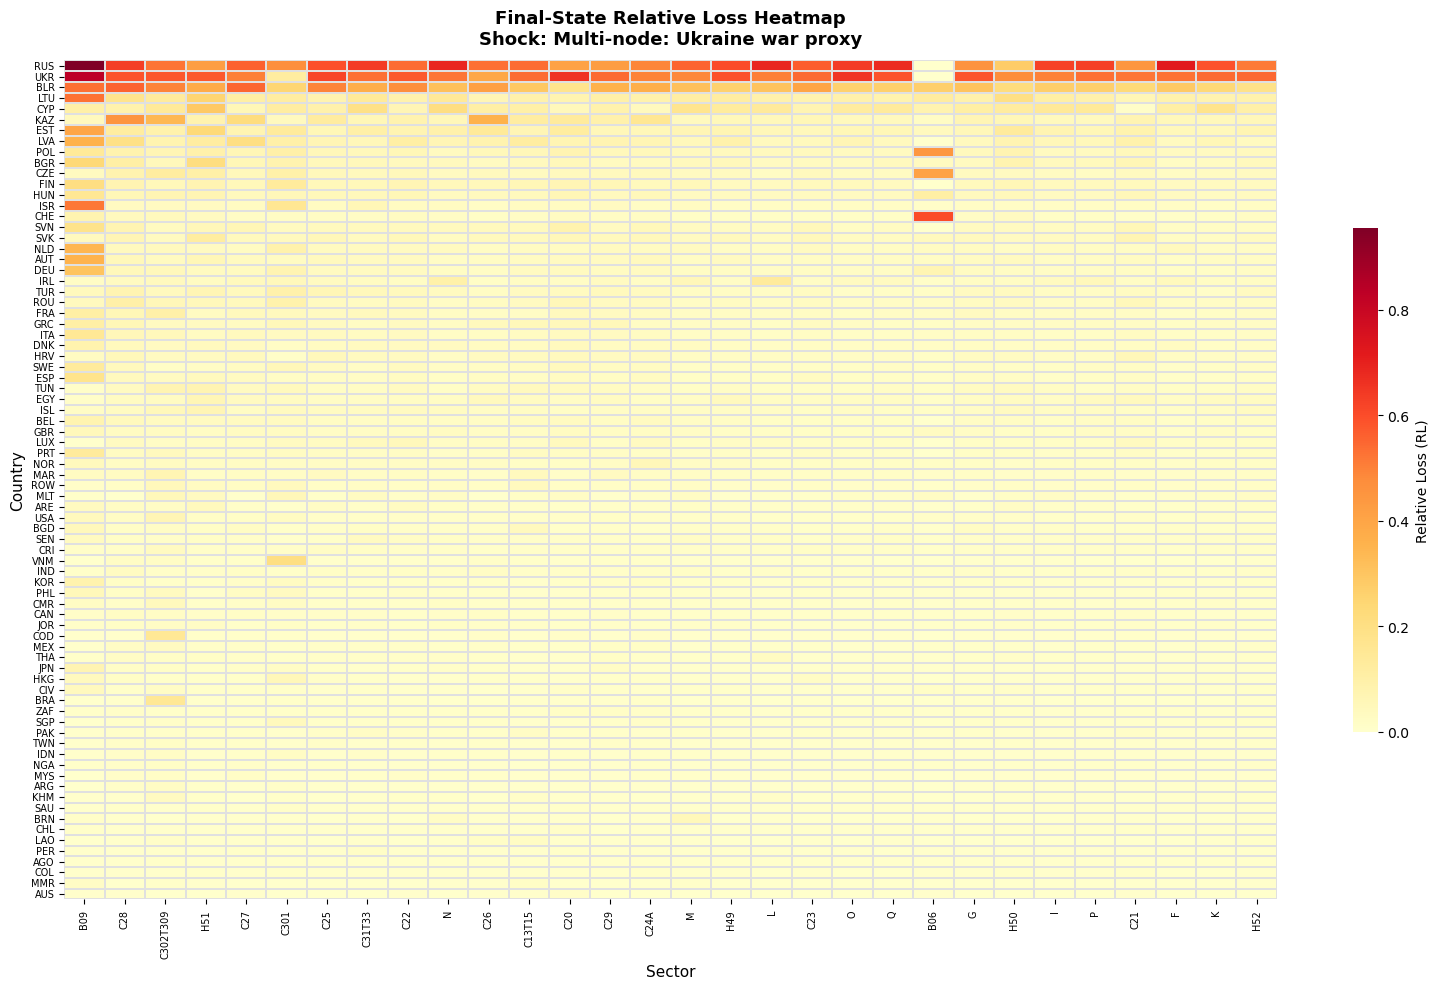

In [21]:
sim.plot_rl_heatmap(
    results_3,
    top_n_nodes=30,
    save_path='../outputs/s3_heatmap.png'
)

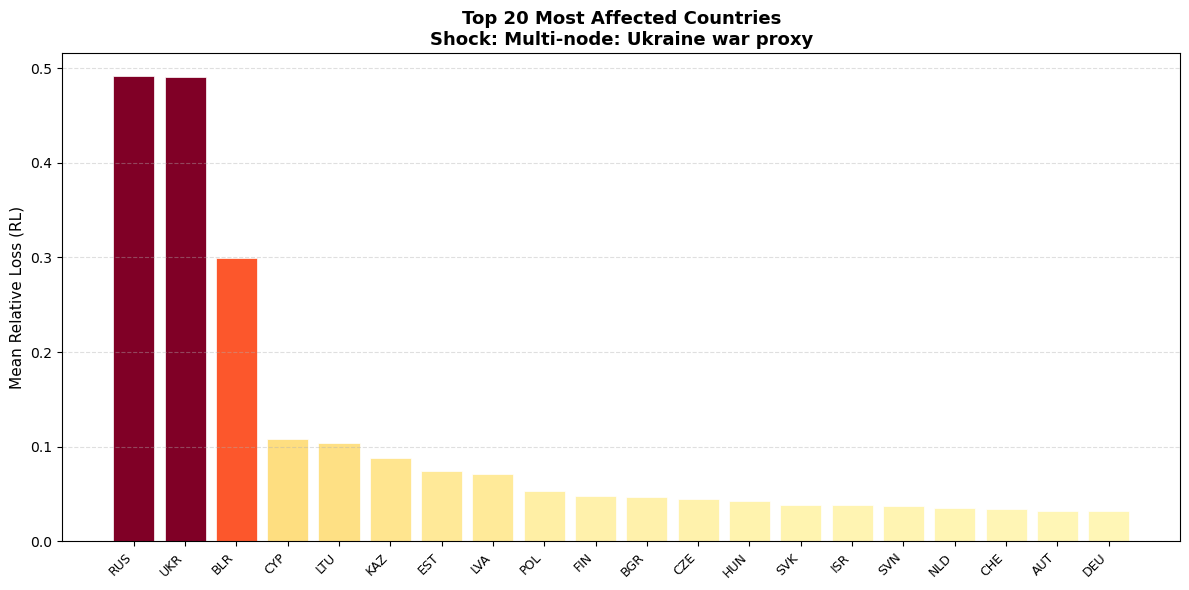

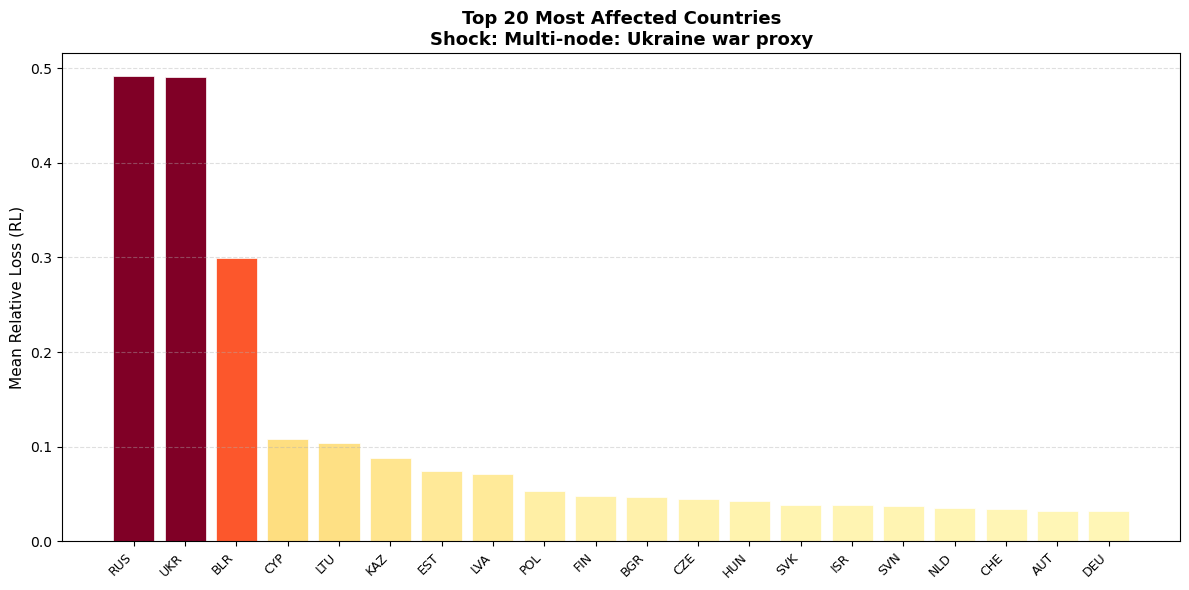

In [22]:
sim.plot_country_rl_bar(
    results_3,
    top_n=20,
    save_path='../outputs/s3_country_bar.png'
)

In [23]:
rl3 = results_3['RL_final'].drop(index=results_3['shock_nodes'], errors='ignore')
print('Top 20 most affected nodes (Scenario 3):')
print(rl3.nlargest(20).to_string())

Top 20 most affected nodes (Scenario 3):
V1
RUS_B09       0.954123
UKR_B09       0.832583
RUS_F         0.721567
RUS_N         0.687461
RUS_L         0.682374
RUS_Q         0.676065
UKR_C20       0.657133
UKR_D         0.657089
UKR_O         0.654136
RUS_C31T33    0.638452
RUS_O         0.638062
RUS_C28       0.630002
RUS_P         0.628038
RUS_I         0.622428
UKR_C25       0.617073
CHE_B06       0.602901
RUS_H49       0.601491
RUS_C25       0.595592
UKR_H49       0.591926
RUS_K         0.589446


---
## Cross-scenario comparison

Compare how much more damage the compound shock does vs. individual shocks.

In [24]:
# ── Summary table ─────────────────────────────────────────────────────────────
all_nodes = set(A.index)

def summary_stats(results, label):
    rl = results['RL_final'].drop(index=results['shock_nodes'], errors='ignore')
    return {
        'Scenario': label,
        'Shocked nodes': len(results['shock_nodes']),
        'Nodes RL>1%': (rl > 0.01).sum(),
        'Nodes RL>10%': (rl > 0.10).sum(),
        'Nodes RL>50%': (rl > 0.50).sum(),
        'Max RL': f"{rl.max():.4f}",
        'Mean RL': f"{rl.mean():.4f}",
        'Worst node': rl.idxmax(),
    }

summary = pd.DataFrame([
    summary_stats(results_1, f'S1: {SHOCK_NODE}'),
    summary_stats(results_2, f'S2: {SHOCK_COUNTRY} (all sectors)'),
    summary_stats(results_3, 'S3: Ukraine war proxy'),
])

print(summary.to_string(index=False))

             Scenario  Shocked nodes  Nodes RL>1%  Nodes RL>10%  Nodes RL>50% Max RL Mean RL Worst node
          S1: RUS_C19              1         2024           188            14 0.8590  0.0253    RUS_B09
S2: RUS (all sectors)             49         3619           339            26 0.8793  0.0504    BLR_C27
S3: Ukraine war proxy              9         2412           237            58 0.9541  0.0366    RUS_B09


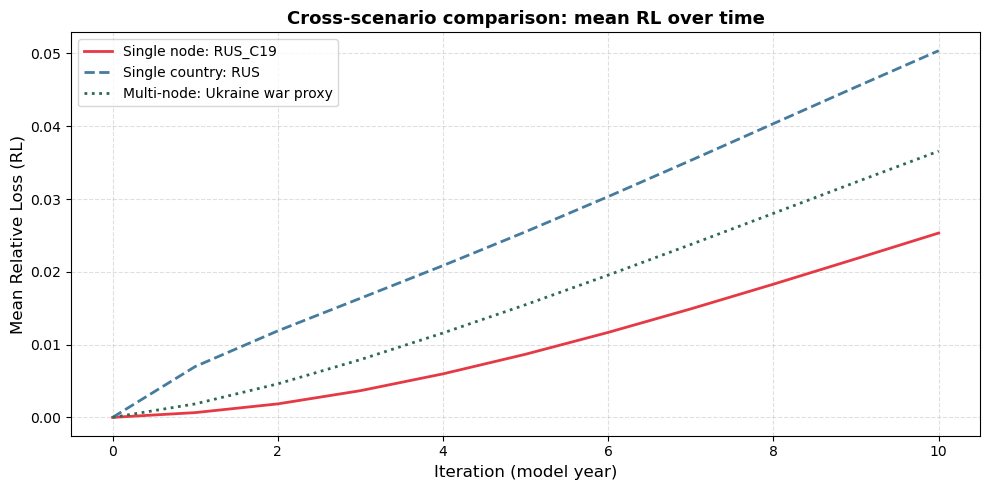

In [25]:
# ── Overlay time-series comparison: mean RL across all non-shocked nodes ──────
fig, ax = plt.subplots(figsize=(10, 5))

for results, color, ls in [
    (results_1, '#e63946', '-'),
    (results_2, '#457b9d', '--'),
    (results_3, '#2d6a4f', ':'),
]:
    rl = results['RL']
    shocked_cols = results['shock_nodes']
    rl_ex = rl.drop(columns=shocked_cols, errors='ignore')
    mean_rl = rl_ex.mean(axis=1)
    ax.plot(
        range(sim.n_iter + 1), mean_rl,
        label=results['label'], color=color, linestyle=ls, linewidth=2
    )

ax.set_xlabel('Iteration (model year)', fontsize=12)
ax.set_ylabel('Mean Relative Loss (RL)', fontsize=12)
ax.set_title('Cross-scenario comparison: mean RL over time', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/comparison_mean_rl.png', dpi=150, bbox_inches='tight')
plt.show()